# Ноутбук 04 — Эконометрические модели: SARIMA и Holt-Winters
**Подраздел 3.2.5 ПЗ** — SARIMA идентификация и оценка  
**Подраздел 3.2.6 ПЗ** — Holt-Winters подбор параметров сглаживания  
**Подраздел 3.3 ПЗ** — результаты

Область применения: агрегированный недельный ряд суммарных продаж  
(сумма по всем 54 магазинам и 33 семействам товаров).  
Обоснование: SARIMA и Holt-Winters требуют единственного временного ряда;  
обучение 1782 отдельных моделей нецелесообразно в рамках академического сравнения.

Артефакты:
- `models/saved/sarima_agg.pkl`  
- `models/saved/holtwinters_agg.pkl`  
- `reports/tables/table_3_metrics_econometric.csv`  
- `reports/figures/fig_3_forecast_sarima.png`  
- `reports/figures/fig_3_forecast_hw.png`  
- `reports/figures/fig_3_sarima_residuals.png`


In [1]:
import sys, warnings, pickle
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 120

# fix Б-0-1: удалены неиспользуемые символы DATA_PROC, TARGET, DATE_COL, STORE_COL, FAMILY_COL
from src.config import (
    DATA_INT, MODELS_DIR, TABLES, FIGURES,
    FORECAST_HORIZONS, TRAIN_CUTOFF, SEASONAL_PERIOD,
)
from src.evaluation.metrics import compute_metrics, metrics_table
from src.models.sarima_model import (
    fit_sarima, sarima_forecast, sarima_residual_diagnostics,
    SARIMA_ORDER, SARIMA_SEASONAL_ORDER,
)
from src.models.ets_model import fit_holtwinters, holtwinters_forecast, holtwinters_params

print("Импорты выполнены.")
print(f"SARIMA спецификация: {SARIMA_ORDER} × {SARIMA_SEASONAL_ORDER}")
print(f"Сезонный период S = {SEASONAL_PERIOD}")


Импорты выполнены.
SARIMA спецификация: (1, 1, 0) × (0, 1, 1, 52)
Сезонный период S = 52


## Ячейка 1 — Загрузка и подготовка агрегированного ряда

Агрегированный недельный ряд суммарных продаж загружается из  
`data/interim/weekly_sales.parquet` (артефакт ноутбука 01, ячейка 7).  
Применяется log1p-преобразование для согласованности с ML-моделями.


Агрегированный ряд: 242 недель
Диапазон: 2013-01-07 — 2017-08-21
Min=762661.9, Max=6959313.2, Mean=4436549.4

После log1p: mean=15.2525, std=0.3410

Train: 225 недель | Test: 17 недель


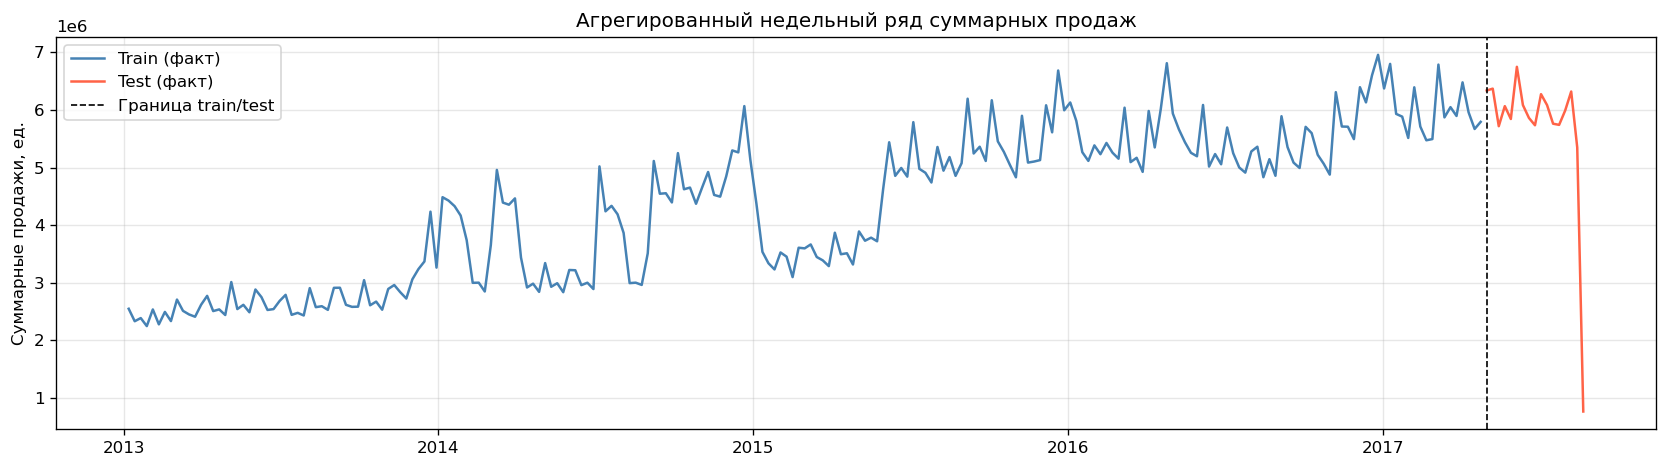

In [2]:
# Загрузка агрегированного ряда
weekly_raw = pd.read_parquet(DATA_INT / "weekly_sales.parquet")
if isinstance(weekly_raw, pd.DataFrame):
    weekly_raw = weekly_raw.iloc[:, 0]
weekly_raw = weekly_raw.sort_index()
weekly_raw.index = pd.to_datetime(weekly_raw.index)
# fix К-1-1: asfreq(method=) удалён — параметр method убран в pandas >= 2.2
weekly_raw = weekly_raw.asfreq("W-MON").ffill()

print(f"Агрегированный ряд: {len(weekly_raw)} недель")
print(f"Диапазон: {weekly_raw.index.min().date()} — {weekly_raw.index.max().date()}")
print(f"Min={weekly_raw.min():.1f}, Max={weekly_raw.max():.1f}, Mean={weekly_raw.mean():.1f}")

# log1p-преобразование
weekly_log = np.log1p(weekly_raw)
print(f"\nПосле log1p: mean={weekly_log.mean():.4f}, std={weekly_log.std():.4f}")

# Разбивка на train/test
cutoff = pd.Timestamp(TRAIN_CUTOFF)
train_series = weekly_log[weekly_log.index < cutoff]
test_series  = weekly_log[weekly_log.index >= cutoff]
print(f"\nTrain: {len(train_series)} недель | Test: {len(test_series)} недель")

# Визуализация
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_series.index, np.expm1(train_series), label="Train (факт)", color="steelblue")
ax.plot(test_series.index,  np.expm1(test_series),  label="Test (факт)",  color="tomato")
ax.axvline(cutoff, color="black", linestyle="--", linewidth=1, label="Граница train/test")
ax.set_title("Агрегированный недельный ряд суммарных продаж")
ax.set_ylabel("Суммарные продажи, ед.")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig_3_weekly_agg_split.png", dpi=120)
plt.show()


## Ячейка 2 — SARIMA: обучение и диагностика

**Спецификация SARIMA(1,1,0)(0,1,1)[52]** выведена в пункте 2.3.4 ПЗ:
- d=1: ADF p=0,4893 (Таблица 2.2), нестационарность подтверждена.
- p=1: единственный значимый лаг ЧАКФ исходного ряда (Рисунок 2.9).
- D=1: нестационарность сезонного компонента STL (Рисунок 2.4).
- Q=1: пик АКФ на лаге 52, без значимого пика ЧАКФ на лаге 52 (Таблица 2.3).


In [3]:
print(f"Обучение SARIMA{SARIMA_ORDER}×{SARIMA_SEASONAL_ORDER}...")
print("(Может занять 1-5 минут для S=52)")

sarima_result = fit_sarima(train_series, SARIMA_ORDER, SARIMA_SEASONAL_ORDER)
print("SARIMA обучен.")
print(f"AIC = {sarima_result.aic:.2f}")
print(f"BIC = {sarima_result.bic:.2f}")
print(f"\nКраткая сводка:")
print(sarima_result.summary().tables[1])


Обучение SARIMA(1, 1, 0)×(0, 1, 1, 52)...
(Может занять 1-5 минут для S=52)
SARIMA обучен.
AIC = -263.62
BIC = -254.18

Краткая сводка:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2277      0.072     -3.179      0.001      -0.368      -0.087
ma.S.L52      -0.7932      0.271     -2.924      0.003      -1.325      -0.262
sigma2         0.0095      0.002      3.930      0.000       0.005       0.014


Тест Льюнга-Бокса (H₀: нет автокорреляции остатков):
     lb_stat  lb_pvalue
10  0.120356        1.0
20  0.256558        1.0

Тест нормальности Жарка-Бера: p = 0.0000


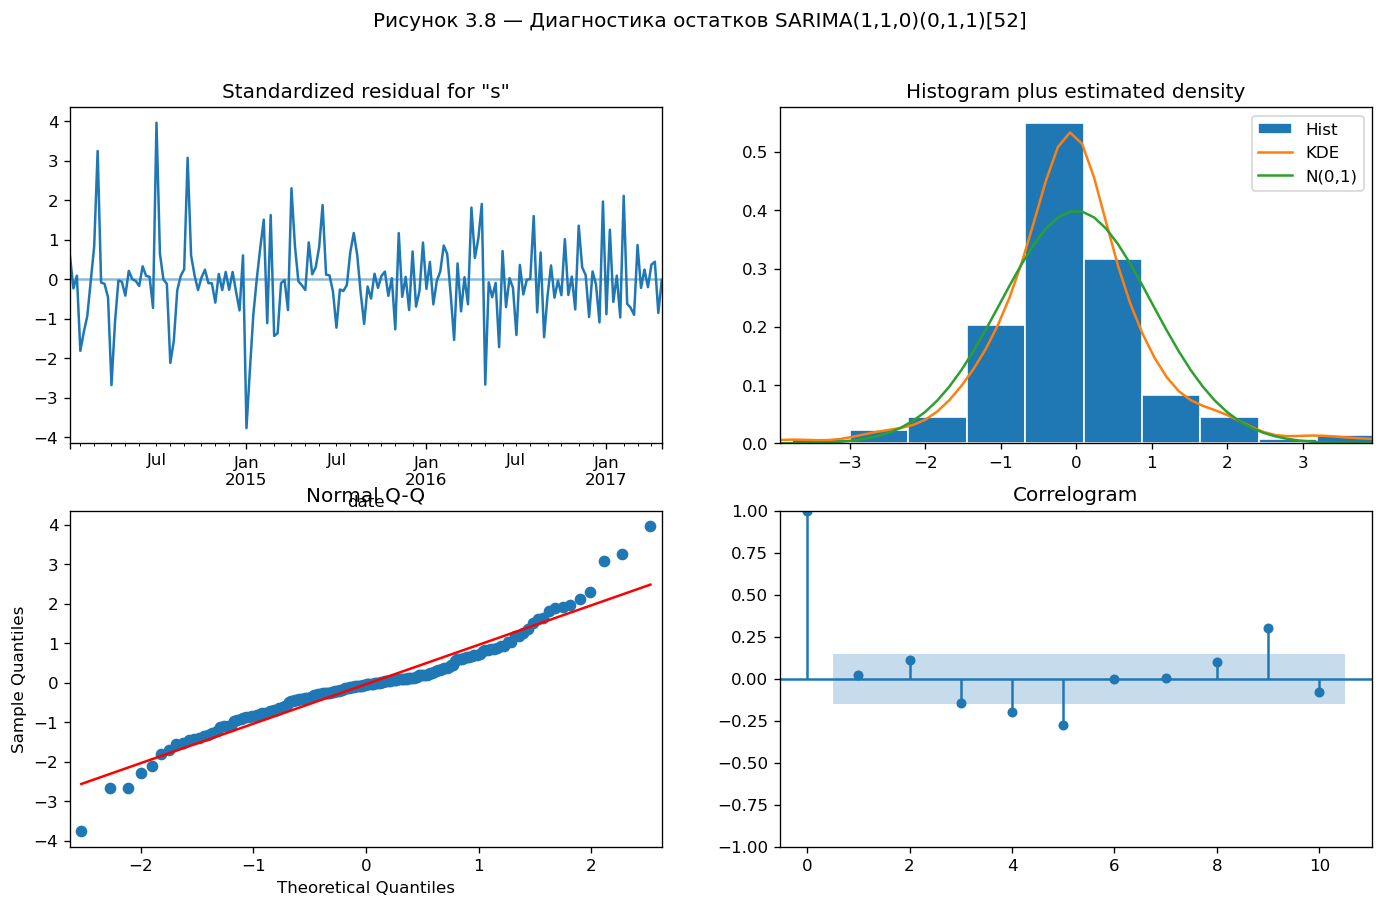

In [4]:
# Диагностика остатков SARIMA
diag = sarima_residual_diagnostics(sarima_result)
print("Тест Льюнга-Бокса (H₀: нет автокорреляции остатков):")
print(diag["ljung_box"].to_string())
print(f"\nТест нормальности Жарка-Бера: p = {diag['jarque_bera_p']:.4f}")

# fix У-2-1: plt.tight_layout() после plot_diagnostics удалён — statsmodels
# управляет компоновкой внутри plot_diagnostics; двойной вызов деформировал поля
fig = sarima_result.plot_diagnostics(figsize=(14, 8))
fig.suptitle("Рисунок 3.8 — Диагностика остатков SARIMA(1,1,0)(0,1,1)[52]")
plt.savefig(FIGURES / "fig_3_sarima_residuals.png", dpi=120, bbox_inches="tight")
plt.show()


## Ячейка 3 — SARIMA: прогноз по горизонтам

Прогноз выполняется методом rolling evaluation (скользящая оценка):  
для каждой тестовой недели модель обновляется с новым наблюдением (append),  
затем делает прогноз на h шагов вперёд.

Это обеспечивает честную сравнительную оценку с ML-моделями.


In [5]:
results_sarima = {}

for h in FORECAST_HORIZONS:
    print(f"\nSARIMA | Горизонт h = {h} нед.")

    actuals_log = []
    preds_log   = []

    history   = train_series.copy()
    test_vals = test_series.values

    for i in range(len(test_vals)):
        if i + h > len(test_vals):
            break

        # fix К-3-1: при i=0 переиспользуем sarima_result вместо повторного рефита;
        # ранее fit_sarima вызывался безусловно на каждой итерации (~207 лишних рефитов)
        if i == 0:
            model_upd = sarima_result
        else:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                new_obs = pd.Series(
                    [test_vals[i - 1]],
                    index=[test_series.index[i - 1]],
                )
                history = pd.concat([history, new_obs])
                model_upd = fit_sarima(history, SARIMA_ORDER, SARIMA_SEASONAL_ORDER)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fc = sarima_forecast(model_upd, steps=h)

        actuals_log.append(test_vals[i + h - 1])
        preds_log.append(fc[-1])

        if i % 3 == 0:
            print(f"  Шаг {i}/{len(test_vals)}: actual={np.expm1(test_vals[i+h-1]):.1f}, "
                  f"pred={np.expm1(fc[-1]):.1f}")

    actuals_log = np.array(actuals_log)
    preds_log   = np.array(preds_log)
    metrics_s   = compute_metrics(actuals_log, preds_log, log_scale=True)
    results_sarima[h] = metrics_s
    # fix И-3-2: добавлены sMAPE и MAPE_nz в progress-лог
    print(f"  SARIMA → RMSE={metrics_s['RMSE']:.2f}, MAE={metrics_s['MAE']:.2f}, "
          f"MAPE={metrics_s['MAPE']:.2f}%, sMAPE={metrics_s['sMAPE']:.2f}%, "
          f"MAPE_nz={metrics_s['MAPE_nz']:.2f}%")

print("\n[OK] SARIMA rolling evaluation завершена.")



SARIMA | Горизонт h = 1 нед.
  Шаг 0/17: actual=6338930.4, pred=6275685.9
  Шаг 3/17: actual=6068016.4, pred=5650680.2
  Шаг 6/17: actual=6086498.8, pred=5865628.7
  Шаг 9/17: actual=6276252.9, pred=7134101.6
  Шаг 12/17: actual=5742574.0, pred=5673230.6
  Шаг 15/17: actual=5348859.3, pred=5978374.5
  SARIMA → RMSE=1247148.80, MAE=655742.72, MAPE=42.99%, sMAPE=15.10%, MAPE_nz=42.99%

SARIMA | Горизонт h = 3 нед.
  Шаг 0/17: actual=5719588.3, pred=5743958.8
  Шаг 3/17: actual=6751157.4, pred=6810494.3
  Шаг 6/17: actual=5735651.2, pred=5934891.0
  Шаг 9/17: actual=5762682.1, pred=6197837.6
  Шаг 12/17: actual=6321801.7, pred=5528224.9
  SARIMA → RMSE=1288726.39, MAE=669847.81, MAPE=46.01%, sMAPE=15.88%, MAPE_nz=46.01%

SARIMA | Горизонт h = 6 нед.
  Шаг 0/17: actual=6751157.4, pred=6697396.8
  Шаг 3/17: actual=5735651.2, pred=6074669.5
  Шаг 6/17: actual=5762682.1, pred=6396683.5
  Шаг 9/17: actual=6321801.7, pred=5871616.0
  SARIMA → RMSE=1514721.13, MAE=873031.84, MAPE=59.60%, sMAPE=

## Ячейка 4 — Holt-Winters: обучение и прогноз

In [6]:
print(f"Обучение Holt-Winters (ETS Add,Add,Add, S={SEASONAL_PERIOD})...")
hw_result = fit_holtwinters(train_series, seasonal_periods=SEASONAL_PERIOD)
print("Holt-Winters обучен.")
hw_p = holtwinters_params(hw_result)
print(f"  alpha = {hw_p['alpha']}  (сглаживание уровня)")
print(f"  beta  = {hw_p['beta']}   (сглаживание тренда)")
print(f"  gamma = {hw_p['gamma']}  (сглаживание сезонности)")
print(f"  SSE   = {hw_p['sse']:.2f}")
print(f"  AIC   = {hw_p['aic']:.2f}")

results_hw = {}
for h in FORECAST_HORIZONS:
    print(f"\nHolt-Winters | Горизонт h = {h} нед.")
    actuals_log = []
    preds_log   = []
    history   = train_series.copy()
    test_vals = test_series.values

    for i in range(len(test_vals)):
        if i + h > len(test_vals):
            break
        if i > 0:
            new_obs = pd.Series([test_vals[i - 1]], index=[test_series.index[i - 1]])
            history = pd.concat([history, new_obs])
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                hw_upd = fit_holtwinters(history, seasonal_periods=SEASONAL_PERIOD)
        else:
            hw_upd = hw_result

        fc = holtwinters_forecast(hw_upd, steps=h)
        actuals_log.append(test_vals[i + h - 1])
        preds_log.append(fc[-1])

    actuals_log = np.array(actuals_log)
    preds_log   = np.array(preds_log)
    metrics_hw  = compute_metrics(actuals_log, preds_log, log_scale=True)
    results_hw[h] = metrics_hw
    # fix И-4-2: добавлены sMAPE и MAPE_nz в progress-лог
    print(f"  HW → RMSE={metrics_hw['RMSE']:.2f}, MAE={metrics_hw['MAE']:.2f}, "
          f"MAPE={metrics_hw['MAPE']:.2f}%, sMAPE={metrics_hw['sMAPE']:.2f}%, "
          f"MAPE_nz={metrics_hw['MAPE_nz']:.2f}%")

print("\n[OK] Holt-Winters завершён.")


Обучение Holt-Winters (ETS Add,Add,Add, S=52)...
Holt-Winters обучен.
  alpha = 0.7977  (сглаживание уровня)
  beta  = 0.0   (сглаживание тренда)
  gamma = 0.0  (сглаживание сезонности)
  SSE   = 1.37
  AIC   = -1035.82

Holt-Winters | Горизонт h = 1 нед.
  HW → RMSE=1242735.71, MAE=679550.44, MAPE=42.82%, sMAPE=15.53%, MAPE_nz=42.82%

Holt-Winters | Горизонт h = 3 нед.
  HW → RMSE=1287882.74, MAE=690044.69, MAPE=45.93%, sMAPE=16.23%, MAPE_nz=45.93%

Holt-Winters | Горизонт h = 6 нед.
  HW → RMSE=1523308.92, MAE=891570.80, MAPE=59.69%, sMAPE=20.39%, MAPE_nz=59.69%

Holt-Winters | Горизонт h = 12 нед.
  HW → RMSE=2220332.18, MAE=1534616.66, MAPE=121.56%, sMAPE=36.74%, MAPE_nz=121.56%

[OK] Holt-Winters завершён.


## Ячейка 5 — Сравнительные графики прогноз vs факт

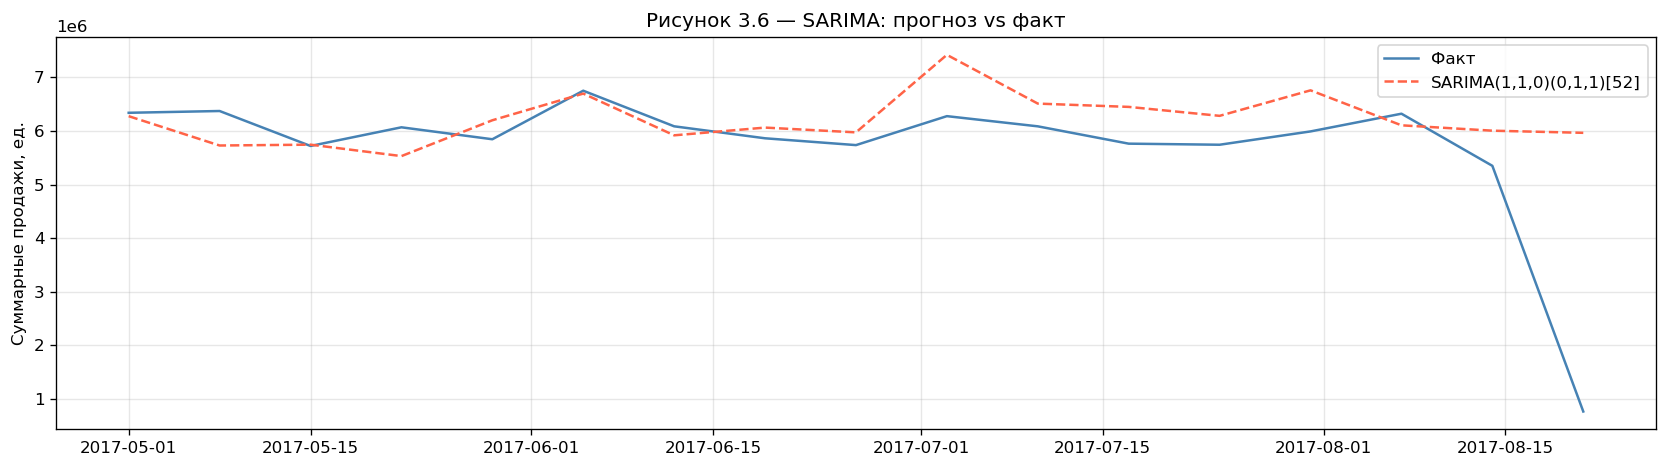

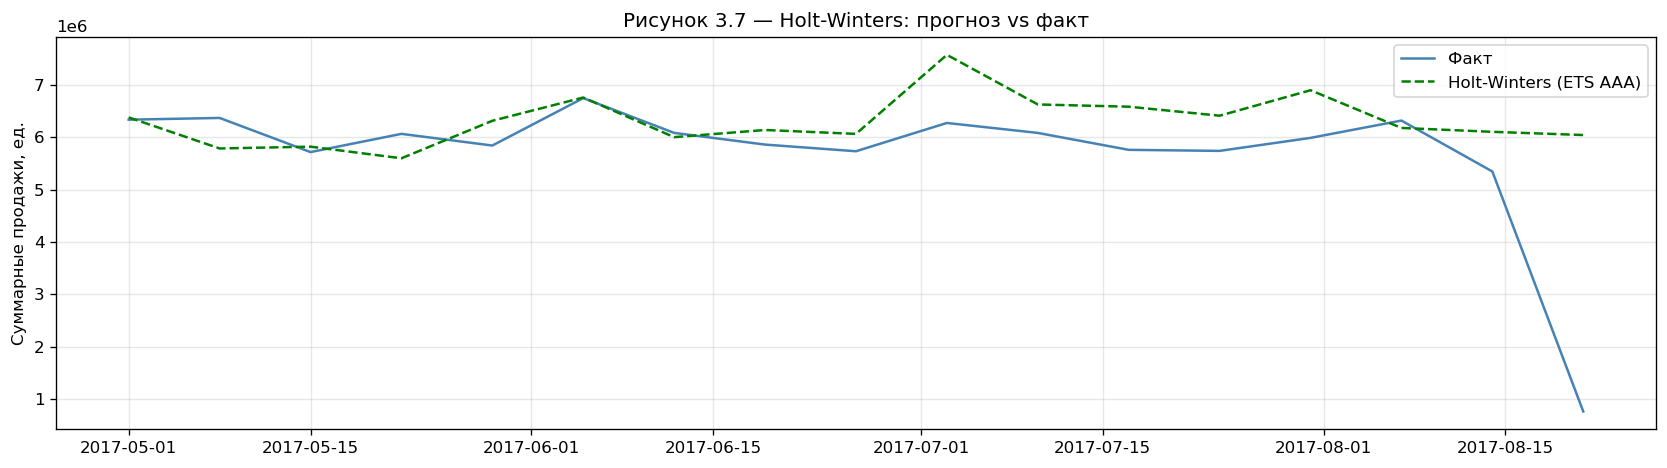

In [7]:
# fix У-5-1: удалена мёртвая переменная h_plot = 1
# Статический прогноз (не rolling) для графика
sarima_fc_static = sarima_forecast(sarima_result, steps=len(test_series))
hw_fc_static     = holtwinters_forecast(hw_result, steps=len(test_series))

actual_orig = np.expm1(test_series.values)
sarima_orig = np.expm1(sarima_fc_static[:len(actual_orig)])
hw_orig     = np.expm1(hw_fc_static[:len(actual_orig)])

# fix У-5-2: вместо единого fig_3_forecast_sarima_hw.png — два отдельных файла
# согласно спецификации артефактов в заголовке ноутбука

# Рисунок 3.6 — SARIMA
fig1, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(test_series.index, actual_orig, label="Факт",
         color="steelblue", linewidth=1.5)
ax1.plot(test_series.index, sarima_orig, label="SARIMA(1,1,0)(0,1,1)[52]",
         color="tomato", linestyle="--", linewidth=1.5)
ax1.set_title("Рисунок 3.6 — SARIMA: прогноз vs факт")
ax1.set_ylabel("Суммарные продажи, ед.")
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig_3_forecast_sarima.png", dpi=120)
plt.show()

# Рисунок 3.7 — Holt-Winters
fig2, ax2 = plt.subplots(figsize=(14, 4))
ax2.plot(test_series.index, actual_orig, label="Факт",
         color="steelblue", linewidth=1.5)
ax2.plot(test_series.index, hw_orig,     label="Holt-Winters (ETS AAA)",
         color="green", linestyle="--", linewidth=1.5)
ax2.set_title("Рисунок 3.7 — Holt-Winters: прогноз vs факт")
ax2.set_ylabel("Суммарные продажи, ед.")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "fig_3_forecast_hw.png", dpi=120)
plt.show()


## Ячейка 6 — Сохранение моделей и таблица метрик

In [8]:
# fix Б-6-1: дублирующий import pickle удалён (импортирован в ячейке 0)

with open(MODELS_DIR / "sarima_agg.pkl", "wb") as f:
    pickle.dump(sarima_result, f)
with open(MODELS_DIR / "holtwinters_agg.pkl", "wb") as f:
    pickle.dump(hw_result, f)

summary_econo = {"SARIMA": results_sarima, "HoltWinters": results_hw}
df_econo = metrics_table(summary_econo)
print("Таблица метрик эконометрических моделей:")
print(df_econo.to_string())
df_econo.to_csv(TABLES / "table_3_metrics_econometric.csv")
print("\nСохранено: reports/tables/table_3_metrics_econometric.csv")


Таблица метрик эконометрических моделей:
                 h=1_RMSE      h=1_MAE  h=1_MAPE  h=1_sMAPE  h=1_MAPE_nz      h=3_RMSE      h=3_MAE  h=3_MAPE  h=3_sMAPE  h=3_MAPE_nz      h=6_RMSE      h=6_MAE  h=6_MAPE  h=6_sMAPE  h=6_MAPE_nz     h=12_RMSE      h=12_MAE  h=12_MAPE  h=12_sMAPE  h=12_MAPE_nz
Модель                                                                                                                                                                                                                                                             
SARIMA       1.247149e+06  655742.7206   42.9857    15.1015      42.9857  1.288726e+06  669847.8052   46.0117     15.878      46.0117  1.514721e+06  873031.8434   59.6043    20.1029      59.6043  2.213734e+06  1.492383e+06   121.4384     36.0597      121.4384
HoltWinters  1.242736e+06  679550.4375   42.8217    15.5256      42.8217  1.287883e+06  690044.6860   45.9314     16.230      45.9314  1.523309e+06  891570.8036   59.6857    20.38

In [9]:
print("=" * 60)
print("Ноутбук 04 выполнен.")
print("=" * 60)


Ноутбук 04 выполнен.
